# Scenario 4 - Continuous Mountain Car: Minimum Non-Null Actions

**Objective:** reach the flag while using as few non-null continuous actions as possible.

**Base environment:** `MountainCarContinuous-v0`

In the normal continuous Mountain Car environment, the cost depends on the size of the action: `-0.1 * action^2`. For this scenario, I changed the reward so that the cost is based on whether the action is used at all:

- `0` if `abs(action) <= non_null_threshold`
- `-1` if `abs(action) > non_null_threshold`
- `+100` when the car reaches the flag

So the agent is not rewarded for using tiny actions. Once it decides to push, a small push and a strong push both count as one paid action. This makes the task about timing: the policy should spend actions only when they help build enough momentum.


## Section 1 - Setup and Dependencies

I kept everything for Scenario 4 inside this notebook so it is easy to run from top to bottom. The first code cell imports the libraries and defines the custom reward wrapper, model builders, callbacks, evaluation helpers, and plotting functions.

TensorBoard logs are saved in `runs/s04_tensorboard`, and the trained models/plots are saved in `checkpoints/`. One small practical note: do not delete the TensorBoard folder while training is still running, because the writer can lose its output path.


In [2]:
import os
import random
import warnings
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import HTML, display
from matplotlib import animation
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text

warnings.filterwarnings('ignore')

SEED = 42
CHECKPOINT_DIR = Path('checkpoints')
RUN_DIR = Path('runs')
SCENARIO_PREFIX = 's04'
USE_TENSORBOARD = True
NON_NULL_THRESHOLD = 1e-3
TENSORBOARD_LOG_DIR = RUN_DIR / 's04_tensorboard'

CHECKPOINT_DIR.mkdir(exist_ok=True)
RUN_DIR.mkdir(exist_ok=True)

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

try:
    import stable_baselines3
    from stable_baselines3 import SAC, TD3
    from stable_baselines3.common.callbacks import BaseCallback
    from stable_baselines3.common.monitor import Monitor
    from stable_baselines3.common.noise import NormalActionNoise
    SB3_AVAILABLE = True
except ModuleNotFoundError as exc:
    stable_baselines3 = None
    SAC = TD3 = BaseCallback = Monitor = NormalActionNoise = None
    SB3_AVAILABLE = False
    SB3_IMPORT_ERROR = exc

print(f'Python environment ready. SB3 available: {SB3_AVAILABLE}')
if SB3_AVAILABLE:
    print(f'stable-baselines3 version: {stable_baselines3.__version__}')
else:
    print('Install missing training dependency with: %pip install stable-baselines3 tensorboard')


def require_sb3():
    if not SB3_AVAILABLE:
        raise ModuleNotFoundError(
            'stable_baselines3 is not installed in this notebook kernel. '
            'Run: %pip install stable-baselines3 tensorboard'
        ) from SB3_IMPORT_ERROR


def action_abs_magnitude(action):
    action_array = np.asarray(action, dtype=np.float32)
    if action_array.size == 0:
        return 0.0
    return float(np.max(np.abs(action_array)))


class LinearNonNullActionCostWrapper(gym.Wrapper):
    """Scenario 4 reward adaptation for MountainCarContinuous-v0."""

    def __init__(self, env, action_cost=1.0, non_null_threshold=NON_NULL_THRESHOLD, goal_bonus=100.0):
        super().__init__(env)
        self.action_cost = float(action_cost)
        self.non_null_threshold = float(non_null_threshold)
        self.goal_bonus = float(goal_bonus)
        self.episode_non_null_actions = 0
        self.episode_linear_action_cost = 0.0
        self.episode_steps = 0

    def reset(self, **kwargs):
        self.episode_non_null_actions = 0
        self.episode_linear_action_cost = 0.0
        self.episode_steps = 0
        return self.env.reset(**kwargs)

    def step(self, action):
        obs, raw_reward, terminated, truncated, info = self.env.step(action)
        action_magnitude = action_abs_magnitude(action)
        non_null_action = action_magnitude > self.non_null_threshold
        linear_action_cost = self.action_cost if non_null_action else 0.0
        goal_bonus = self.goal_bonus if terminated else 0.0
        reward = goal_bonus - linear_action_cost

        self.episode_steps += 1
        if non_null_action:
            self.episode_non_null_actions += 1
        self.episode_linear_action_cost += linear_action_cost

        info = dict(info)
        info.update({
            'raw_reward': float(raw_reward),
            'action_magnitude': action_magnitude,
            'non_null_action': non_null_action,
            'linear_action_cost': linear_action_cost,
            'goal_bonus': goal_bonus,
            'episode_non_null_actions': self.episode_non_null_actions,
            'episode_linear_action_cost': self.episode_linear_action_cost,
            'episode_steps': self.episode_steps,
        })
        return obs, reward, terminated, truncated, info


def make_scenario4_env(render_mode=None, action_cost=1.0, non_null_threshold=NON_NULL_THRESHOLD, goal_bonus=100.0):
    env = gym.make('MountainCarContinuous-v0', render_mode=render_mode)
    return LinearNonNullActionCostWrapper(
        env,
        action_cost=action_cost,
        non_null_threshold=non_null_threshold,
        goal_bonus=goal_bonus,
    )


def tensorboard_log_dir():
    if not USE_TENSORBOARD:
        return None
    TENSORBOARD_LOG_DIR.mkdir(parents=True, exist_ok=True)
    return str(TENSORBOARD_LOG_DIR)


if SB3_AVAILABLE:
    class EpisodeMetricsCallback(BaseCallback):
        """Stores per-episode metrics from Monitor and wrapper info."""

        def __init__(self):
            super().__init__()
            self.episode_rewards = []
            self.episode_lengths = []
            self.non_null_counts = []
            self.linear_costs = []
            self.successes = []

        def _on_step(self):
            infos = self.locals.get('infos', [])
            dones = self.locals.get('dones', [])
            for info, done in zip(infos, dones):
                if not done:
                    continue
                episode_info = info.get('episode', {})
                self.episode_rewards.append(float(episode_info.get('r', np.nan)))
                self.episode_lengths.append(int(episode_info.get('l', info.get('episode_steps', 0))))
                self.non_null_counts.append(int(info.get('episode_non_null_actions', 0)))
                self.linear_costs.append(float(info.get('episode_linear_action_cost', 0.0)))
                self.successes.append(bool(info.get('goal_bonus', 0.0) > 0.0))
            return True

        def as_dict(self):
            return {
                'episode_rewards': np.array(self.episode_rewards, dtype=float),
                'episode_lengths': np.array(self.episode_lengths, dtype=float),
                'non_null_counts': np.array(self.non_null_counts, dtype=float),
                'linear_costs': np.array(self.linear_costs, dtype=float),
                'successes': np.array(self.successes, dtype=float),
            }


    class SuccessEvalCallback(BaseCallback):
        """Periodic evaluation; saves best model by success rate, then lower action count."""

        def __init__(self, eval_env, label, eval_freq=5000, n_eval_episodes=10):
            super().__init__()
            self.eval_env = eval_env
            self.label = label
            self.eval_freq = int(eval_freq)
            self.n_eval_episodes = int(n_eval_episodes)
            self.best_success_rate = -1.0
            self.best_mean_non_null = np.inf
            self.best_mean_reward = -np.inf
            self.history = []
            self.save_path = CHECKPOINT_DIR / f'{SCENARIO_PREFIX}_{label.lower()}_best'
            self.save_path.mkdir(exist_ok=True)

        def _on_step(self):
            if self.eval_freq <= 0 or self.n_calls % self.eval_freq != 0:
                return True
            metrics = evaluate_model(self.model, self.eval_env, n_episodes=self.n_eval_episodes, seed=SEED + 20000)
            row = {
                'timesteps': self.num_timesteps,
                'mean_reward': metrics['mean_reward'],
                'success_rate': metrics['success_rate'],
                'mean_non_null_actions': metrics['mean_non_null_actions'],
            }
            self.history.append(row)
            print(
                f"[{self.label} eval] steps={self.num_timesteps} "
                f"reward={row['mean_reward']:.2f} success={100*row['success_rate']:.0f}% "
                f"non_null={row['mean_non_null_actions']:.1f}"
            )
            is_better = (
                row['success_rate'] > self.best_success_rate
                or (
                    np.isclose(row['success_rate'], self.best_success_rate)
                    and row['mean_non_null_actions'] < self.best_mean_non_null
                )
                or (
                    np.isclose(row['success_rate'], self.best_success_rate)
                    and np.isclose(row['mean_non_null_actions'], self.best_mean_non_null)
                    and row['mean_reward'] > self.best_mean_reward
                )
            )
            if is_better:
                self.best_success_rate = row['success_rate']
                self.best_mean_non_null = row['mean_non_null_actions']
                self.best_mean_reward = row['mean_reward']
                self.model.save(self.save_path / 'best_model')
            return True

else:
    EpisodeMetricsCallback = None
    SuccessEvalCallback = None


def build_sac_model(env=None, seed=SEED):
    require_sb3()
    env = Monitor(env or make_scenario4_env())
    return SAC(
        'MlpPolicy',
        env,
        learning_rate=3e-4,
        buffer_size=50000,
        learning_starts=0,
        batch_size=512,
        tau=0.01,
        gamma=0.9999,
        train_freq=32,
        gradient_steps=32,
        ent_coef=0.1,
        use_sde=True,
        verbose=0,
        tensorboard_log=tensorboard_log_dir(),
        policy_kwargs=dict(log_std_init=-3.67, net_arch=[64, 64]),
        seed=seed,
    )


def build_td3_model(env=None, seed=SEED):
    require_sb3()
    env = Monitor(env or make_scenario4_env())
    action_dim = env.action_space.shape[-1]
    noise = NormalActionNoise(mean=np.zeros(action_dim), sigma=0.25 * np.ones(action_dim))
    return TD3(
        'MlpPolicy',
        env,
        learning_rate=3e-4,
        buffer_size=100000,
        learning_starts=0,
        batch_size=256,
        tau=0.01,
        gamma=0.995,
        train_freq=(1, 'step'),
        gradient_steps=1,
        action_noise=noise,
        policy_delay=2,
        verbose=0,
        tensorboard_log=tensorboard_log_dir(),
        policy_kwargs=dict(net_arch=[64, 64]),
        seed=seed,
    )


AGENT_BUILDERS = {
    'SAC': build_sac_model,
    'TD3': build_td3_model,
}


def resonant_continuous_policy(state, coast_velocity=0.045, coast_position_limit=0.25):
    """Simple physics policy: coast at high speed, otherwise push with velocity."""
    position, velocity = np.asarray(state, dtype=np.float32)
    if abs(float(velocity)) > coast_velocity and float(position) < coast_position_limit:
        return np.array([0.0], dtype=np.float32)
    force = 1.0 if velocity >= 0.0 else -1.0
    return np.array([force], dtype=np.float32)


def evaluate_action_sequence(env, actions, seed=None):
    state, _ = env.reset(seed=seed) if seed is not None else env.reset()
    total_reward = 0.0
    non_null_actions = 0
    linear_action_cost = 0.0
    action_magnitudes = []
    steps = 0
    success = False

    for action in actions:
        state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        non_null_actions = info.get('episode_non_null_actions', non_null_actions)
        linear_action_cost = info.get('episode_linear_action_cost', linear_action_cost)
        action_magnitudes.append(info.get('action_magnitude', action_abs_magnitude(action)))
        steps += 1
        success = success or terminated
        if terminated or truncated:
            break

    return {
        'total_reward': total_reward,
        'non_null_actions': non_null_actions,
        'linear_action_cost': linear_action_cost,
        'mean_action_magnitude': float(np.mean(action_magnitudes)) if action_magnitudes else 0.0,
        'steps': steps,
        'success': success,
        'final_state': np.asarray(state, dtype=np.float32),
    }


def rollout_policy(env, policy_fn, seed=1000, max_steps=999):
    state, _ = env.reset(seed=seed)
    states = [state.copy()]
    actions = []
    rewards = []
    infos = []
    done = False
    steps = 0

    while not done and steps < max_steps:
        action = np.asarray(policy_fn(state), dtype=np.float32).reshape(env.action_space.shape)
        state, reward, terminated, truncated, info = env.step(action)
        states.append(state.copy())
        actions.append(action.copy())
        rewards.append(float(reward))
        infos.append(info)
        done = terminated or truncated
        steps += 1

    return {
        'states': np.array(states),
        'actions': np.array(actions).reshape(-1),
        'rewards': np.array(rewards, dtype=float),
        'infos': infos,
        'total_reward': float(np.sum(rewards)),
        'success': bool(infos[-1].get('goal_bonus', 0.0) > 0.0) if infos else False,
        'non_null_actions': int(infos[-1].get('episode_non_null_actions', 0)) if infos else 0,
        'linear_action_cost': float(infos[-1].get('episode_linear_action_cost', 0.0)) if infos else 0.0,
        'steps': steps,
    }


def evaluate_model(model, env=None, n_episodes=100, seed=1000):
    env = env or make_scenario4_env()
    episode_rows = []
    for ep in range(n_episodes):
        traj = rollout_policy(env, lambda s: model.predict(s, deterministic=True)[0], seed=seed + ep)
        episode_rows.append(traj)

    rewards = np.array([r['total_reward'] for r in episode_rows], dtype=float)
    successes = np.array([r['success'] for r in episode_rows], dtype=float)
    steps = np.array([r['steps'] for r in episode_rows], dtype=float)
    non_null = np.array([r['non_null_actions'] for r in episode_rows], dtype=float)
    linear_costs = np.array([r['linear_action_cost'] for r in episode_rows], dtype=float)
    mean_abs_actions = np.array([
        float(np.mean(np.abs(r['actions']))) if len(r['actions']) else 0.0
        for r in episode_rows
    ])

    return {
        'episodes': episode_rows,
        'rewards': rewards,
        'mean_reward': float(np.mean(rewards)) if len(rewards) else 0.0,
        'std_reward': float(np.std(rewards)) if len(rewards) else 0.0,
        'success_rate': float(np.mean(successes)) if len(successes) else 0.0,
        'steps': steps,
        'mean_steps': float(np.mean(steps)) if len(steps) else 0.0,
        'non_null_actions': non_null,
        'mean_non_null_actions': float(np.mean(non_null)) if len(non_null) else 0.0,
        'linear_action_costs': linear_costs,
        'mean_linear_action_cost': float(np.mean(linear_costs)) if len(linear_costs) else 0.0,
        'mean_abs_actions': mean_abs_actions,
        'mean_abs_action': float(np.mean(mean_abs_actions)) if len(mean_abs_actions) else 0.0,
    }


def evaluate_random_policy(env=None, n_episodes=100, seed=1000):
    env = env or make_scenario4_env()
    episode_rows = []
    rng = np.random.default_rng(seed)
    for ep in range(n_episodes):
        traj = rollout_policy(
            env,
            lambda s: rng.uniform(env.action_space.low, env.action_space.high),
            seed=seed + ep,
        )
        episode_rows.append(traj)

    rewards = np.array([r['total_reward'] for r in episode_rows], dtype=float)
    successes = np.array([r['success'] for r in episode_rows], dtype=float)
    non_null = np.array([r['non_null_actions'] for r in episode_rows], dtype=float)
    steps = np.array([r['steps'] for r in episode_rows], dtype=float)
    return {
        'episodes': episode_rows,
        'rewards': rewards,
        'mean_reward': float(np.mean(rewards)),
        'std_reward': float(np.std(rewards)),
        'success_rate': float(np.mean(successes)),
        'non_null_actions': non_null,
        'mean_non_null_actions': float(np.mean(non_null)),
        'steps': steps,
        'mean_steps': float(np.mean(steps)),
        'mean_linear_action_cost': float(np.mean(non_null)),
        'mean_abs_action': float(np.mean([np.mean(np.abs(r['actions'])) for r in episode_rows])),
    }


def evaluate_policy_function(policy_fn, env=None, n_episodes=100, seed=1000):
    env = env or make_scenario4_env()
    episode_rows = []
    for ep in range(n_episodes):
        traj = rollout_policy(env, policy_fn, seed=seed + ep)
        episode_rows.append(traj)

    rewards = np.array([r['total_reward'] for r in episode_rows], dtype=float)
    successes = np.array([r['success'] for r in episode_rows], dtype=float)
    non_null = np.array([r['non_null_actions'] for r in episode_rows], dtype=float)
    steps = np.array([r['steps'] for r in episode_rows], dtype=float)
    mean_abs_actions = np.array([
        float(np.mean(np.abs(r['actions']))) if len(r['actions']) else 0.0
        for r in episode_rows
    ])
    return {
        'episodes': episode_rows,
        'rewards': rewards,
        'mean_reward': float(np.mean(rewards)),
        'std_reward': float(np.std(rewards)),
        'success_rate': float(np.mean(successes)),
        'non_null_actions': non_null,
        'mean_non_null_actions': float(np.mean(non_null)),
        'steps': steps,
        'mean_steps': float(np.mean(steps)),
        'mean_linear_action_cost': float(np.mean(non_null)),
        'mean_abs_actions': mean_abs_actions,
        'mean_abs_action': float(np.mean(mean_abs_actions)),
    }


def prefill_replay_buffer_with_policy(model, policy_fn, n_episodes=200, seed=SEED + 50000):
    """Warm-start off-policy agents with successful Scenario 4 transitions."""
    env = make_scenario4_env()
    transitions = 0
    successes = 0
    non_null_counts = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        while not done:
            action = np.asarray(policy_fn(obs), dtype=np.float32).reshape(env.action_space.shape)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            model.replay_buffer.add(
                obs,
                next_obs,
                action,
                np.array([reward], dtype=np.float32),
                np.array([done], dtype=bool),
                [info],
            )
            obs = next_obs
            transitions += 1

        successes += int(info.get('goal_bonus', 0.0) > 0.0)
        non_null_counts.append(info.get('episode_non_null_actions', 0))

    env.close()
    return {
        'episodes': n_episodes,
        'transitions': transitions,
        'success_rate': successes / n_episodes if n_episodes else 0.0,
        'mean_non_null_actions': float(np.mean(non_null_counts)) if non_null_counts else 0.0,
    }


def train_agent(label, total_timesteps=50000, seed=SEED, eval_freq=5000, n_eval_episodes=10, td3_prefill_episodes=200):
    require_sb3()
    builder = AGENT_BUILDERS[label]
    model = builder(seed=seed)

    if label == 'TD3' and td3_prefill_episodes > 0:
        prefill = prefill_replay_buffer_with_policy(
            model,
            resonant_continuous_policy,
            n_episodes=td3_prefill_episodes,
            seed=seed + 50000,
        )
        print(
            f"TD3 replay warm-start: {prefill['transitions']} transitions, "
            f"{100 * prefill['success_rate']:.0f}% heuristic success, "
            f"{prefill['mean_non_null_actions']:.1f} non-null actions/episode"
        )

    train_callback = EpisodeMetricsCallback()
    eval_callback = SuccessEvalCallback(make_scenario4_env(), label, eval_freq=eval_freq, n_eval_episodes=n_eval_episodes)
    model.learn(
        total_timesteps=total_timesteps,
        callback=[train_callback, eval_callback],
        log_interval=50,
        tb_log_name=f'{SCENARIO_PREFIX}_{label.lower()}',
    )
    model.save(CHECKPOINT_DIR / f'{SCENARIO_PREFIX}_{label.lower()}_last')
    return model, train_callback.as_dict(), eval_callback.history


def moving_average(values, window=50):
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return np.array([]), np.array([])
    ma = np.convolve(values, np.ones(window) / window, mode='valid')
    return np.arange(window - 1, len(values)), ma


def state_grid(env, n_grid=60):
    pos_low, vel_low = env.observation_space.low
    pos_high, vel_high = env.observation_space.high
    pos = np.linspace(pos_low, pos_high, n_grid)
    vel = np.linspace(vel_low, vel_high, n_grid)
    return pos, vel


def model_action(model, state):
    return float(np.asarray(model.predict(state, deterministic=True)[0]).reshape(-1)[0])


def print_metric_table(results):
    print(f"{'Agent':<10} {'Mean reward':>13} {'Success':>10} {'Non-null':>12} {'Steps':>10} {'|action|':>10}")
    print('-' * 70)
    for name, metrics in results.items():
        print(
            f"{name:<10} "
            f"{metrics['mean_reward']:>13.2f} "
            f"{100 * metrics['success_rate']:>9.1f}% "
            f"{metrics['mean_non_null_actions']:>12.1f} "
            f"{metrics['mean_steps']:>10.1f} "
            f"{metrics.get('mean_abs_action', 0.0):>10.3f}"
        )


print('Scenario 4 setup complete.')


Python environment ready. SB3 available: True
stable-baselines3 version: 2.8.0
Scenario 4 setup complete.


## Section 2 - Environment and Reward Adaptation

The state is still the usual Mountain Car state: position and velocity. The difference is that the action is continuous, so the agent chooses one force value between `-1` and `1`.

The wrapper below replaces the original quadratic reward with the Scenario 4 reward. This makes the objective very easy to check:

```
episode reward = 100 * success - number_of_non_null_actions
```

A positive reward means the car reached the flag in fewer than 100 paid actions. A failed episode with many non-null actions becomes very negative, which is why early training can look bad before the agent discovers a successful strategy.


In [3]:
raw_env = gym.make('MountainCarContinuous-v0')
wrapped_env = make_scenario4_env(non_null_threshold=NON_NULL_THRESHOLD)
raw_env.reset(seed=SEED)
wrapped_env.reset(seed=SEED)

print('=== MountainCarContinuous-v0 / Scenario 4 ===')
print(f'Observation space: {raw_env.observation_space}')
print(f'Action space: {raw_env.action_space}')
print('Original reward: -0.1 * action^2 + 100 at goal')
print('Scenario 4 reward: -1 per non-null action + 100 at goal')

print('\nReward sanity check:')
state, _ = wrapped_env.reset(seed=SEED)
for action in [
    np.array([0.0], dtype=np.float32),
    np.array([NON_NULL_THRESHOLD / 2], dtype=np.float32),
    np.array([NON_NULL_THRESHOLD * 2], dtype=np.float32),
    np.array([1.0], dtype=np.float32),
]:
    _, reward, terminated, truncated, info = wrapped_env.step(action)
    print(
        f'action={float(action[0]):+.4f}  reward={reward:+.1f}  '
        f'non_null={info["non_null_action"]}  '
        f'episode_non_null={info["episode_non_null_actions"]}'
    )
    if terminated or truncated:
        break

raw_env.close()
wrapped_env.close()


=== MountainCarContinuous-v0 / Scenario 4 ===
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Box(-1.0, 1.0, (1,), float32)
Original reward: -0.1 * action^2 + 100 at goal
Scenario 4 reward: -1 per non-null action + 100 at goal

Reward sanity check:
action=+0.0000  reward=+0.0  non_null=False  episode_non_null=0
action=+0.0005  reward=+0.0  non_null=False  episode_non_null=0
action=+0.0020  reward=-1.0  non_null=True  episode_non_null=1
action=+1.0000  reward=-1.0  non_null=True  episode_non_null=2


## Section 3 - Baseline Testbed

Before training SAC and TD3, I use two simple baselines.

The random policy is the lower bound. Since almost every random continuous action is non-null, it spends fuel almost every timestep and usually gets a very poor reward.

The physics policy is a simple hand-written sanity check. It pushes in the direction of movement and coasts when the car already has enough speed. It is not the final RL solution, but it shows that the reward setup makes sense: reaching the flag with fewer paid actions gives a positive score.


In [4]:
random_eval = evaluate_random_policy(make_scenario4_env(), n_episodes=20, seed=SEED)
heuristic_eval = evaluate_policy_function(resonant_continuous_policy, make_scenario4_env(), n_episodes=100, seed=SEED)
print_metric_table({'Random': random_eval, 'Physics': heuristic_eval})


Agent        Mean reward    Success     Non-null      Steps   |action|
----------------------------------------------------------------------
Random           -990.70       5.0%        995.7      996.9      0.500
Physics             5.98     100.0%         94.0      115.7      0.814


## Section 4 - Algorithms

Because the action is continuous, a tabular Q-table would not be a natural choice unless we discretised the action space. That would remove the main point of this scenario, so I use two continuous-control algorithms instead.

- **SAC:** a stochastic actor-critic method. It is useful here because the goal reward is sparse at the beginning, so exploration matters.
- **TD3:** a deterministic actor-critic method. It can learn a sharper force policy, but it is more sensitive to whether it has seen successful trajectories.

TD3 therefore gets a replay warm-start from the simple physics controller. This is only a training aid: the final evaluation still uses the same Scenario 4 reward as SAC.


In [5]:
TRAIN_TIMESTEPS = 50000
EVAL_FREQ = 5000
N_EVAL_EPISODES_DURING_TRAINING = 10
TD3_PREFILL_EPISODES = 200
AGENTS_TO_TRAIN = ['SAC', 'TD3']

print(f'Agents: {AGENTS_TO_TRAIN}')
print(f'Train timesteps per agent: {TRAIN_TIMESTEPS:,}')
print(f'TD3 replay warm-start episodes: {TD3_PREFILL_EPISODES}')
print(f'TensorBoard enabled: {USE_TENSORBOARD}')
if USE_TENSORBOARD:
    print(f'TensorBoard logs: {TENSORBOARD_LOG_DIR}')


Agents: ['SAC', 'TD3']
Train timesteps per agent: 50,000
TD3 replay warm-start episodes: 200
TensorBoard enabled: True
TensorBoard logs: runs/s04_tensorboard


## Section 5 - Training

This cell trains SAC and TD3 and stores the information needed for the plots. SAC trains normally from its own exploration. TD3 first receives a small set of successful transitions from the physics controller, then continues learning on the real Scenario 4 environment.

For a quick test run, `TRAIN_TIMESTEPS` can be reduced, but the final results below use the full training budget.


In [6]:
models = {}
training_histories = {}
eval_histories = {}

for agent_name in AGENTS_TO_TRAIN:
    print(f'\nTraining {agent_name} on Scenario 4...')
    model, train_history, eval_history = train_agent(
        agent_name,
        total_timesteps=TRAIN_TIMESTEPS,
        seed=SEED,
        eval_freq=EVAL_FREQ,
        n_eval_episodes=N_EVAL_EPISODES_DURING_TRAINING,
        td3_prefill_episodes=TD3_PREFILL_EPISODES,
    )
    models[agent_name] = model
    training_histories[agent_name] = train_history
    eval_histories[agent_name] = eval_history
    print(f'{agent_name} training complete. Episodes observed: {len(train_history["episode_rewards"])}')

print('\nAll Scenario 4 training complete.')



Training SAC on Scenario 4...
[SAC eval] steps=5000 reward=-999.00 success=0% non_null=999.0
[SAC eval] steps=10000 reward=-603.00 success=100% non_null=703.0
[SAC eval] steps=15000 reward=15.30 success=100% non_null=84.7
[SAC eval] steps=20000 reward=17.20 success=100% non_null=82.8
[SAC eval] steps=25000 reward=21.80 success=100% non_null=78.2
[SAC eval] steps=30000 reward=26.10 success=100% non_null=73.9
[SAC eval] steps=35000 reward=26.40 success=100% non_null=73.6
[SAC eval] steps=40000 reward=28.60 success=100% non_null=71.4
[SAC eval] steps=45000 reward=28.60 success=100% non_null=71.4
[SAC eval] steps=50000 reward=28.60 success=100% non_null=71.4
SAC training complete. Episodes observed: 503

Training TD3 on Scenario 4...
TD3 replay warm-start: 23263 transitions, 100% heuristic success, 93.6 non-null actions/episode
[TD3 eval] steps=5000 reward=-990.60 success=0% non_null=990.6
[TD3 eval] steps=10000 reward=-969.70 success=0% non_null=969.7
[TD3 eval] steps=15000 reward=-999.0

## Section 6 - Training Curves and Monitoring

These plots show both the learning reward and the actual behaviour we care about. In Scenario 4, reward improves only when the agent both reaches the flag and reduces the number of paid actions.

The early negative points are expected. They usually mean the policy failed to reach the goal and kept producing non-null actions until the time limit.


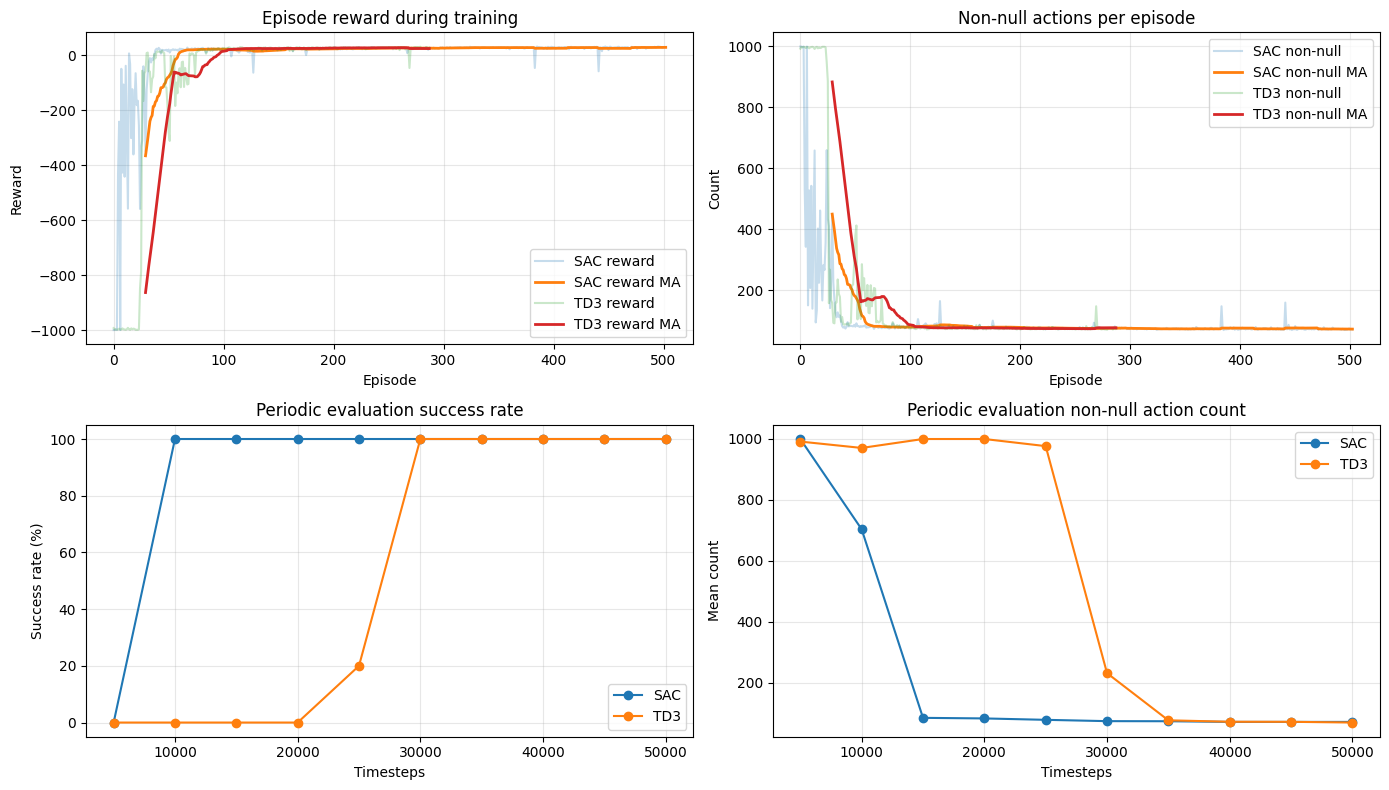

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
window = 30

for name, history in training_histories.items():
    rewards = history['episode_rewards']
    non_null = history['non_null_counts']
    axes[0, 0].plot(rewards, alpha=0.25, label=f'{name} reward')
    x, ma = moving_average(rewards, window=window)
    if len(ma):
        axes[0, 0].plot(x, ma, lw=2, label=f'{name} reward MA')

    axes[0, 1].plot(non_null, alpha=0.25, label=f'{name} non-null')
    x, ma = moving_average(non_null, window=window)
    if len(ma):
        axes[0, 1].plot(x, ma, lw=2, label=f'{name} non-null MA')

for name, history in eval_histories.items():
    if not history:
        continue
    steps = [row['timesteps'] for row in history]
    success = [100 * row['success_rate'] for row in history]
    non_null = [row['mean_non_null_actions'] for row in history]
    axes[1, 0].plot(steps, success, marker='o', label=name)
    axes[1, 1].plot(steps, non_null, marker='o', label=name)

axes[0, 0].set_title('Episode reward during training')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Reward')
axes[0, 1].set_title('Non-null actions per episode')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Count')
axes[1, 0].set_title('Periodic evaluation success rate')
axes[1, 0].set_xlabel('Timesteps')
axes[1, 0].set_ylabel('Success rate (%)')
axes[1, 1].set_title('Periodic evaluation non-null action count')
axes[1, 1].set_xlabel('Timesteps')
axes[1, 1].set_ylabel('Mean count')

for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 's04_training_curves.png', dpi=150)
plt.show()


## Section 7 - Evaluation

The final evaluation uses deterministic rollouts with seeds that are separate from training. The most important numbers are success rate and mean non-null actions.

Mean reward is still useful, but it should be interpreted together with success. A policy that avoids acting forever would have low cost, but it would not solve the task.


In [8]:
evaluation_results = {'Random': random_eval, 'Physics': heuristic_eval}
for name, model in models.items():
    evaluation_results[name] = evaluate_model(model, make_scenario4_env(), n_episodes=100, seed=1000)

print_metric_table(evaluation_results)


Agent        Mean reward    Success     Non-null      Steps   |action|
----------------------------------------------------------------------
Random           -990.70       5.0%        995.7      996.9      0.500
Physics             5.98     100.0%         94.0      115.7      0.814
SAC                28.09     100.0%         71.9       71.9      0.906
TD3                30.75     100.0%         69.2       69.2      0.985


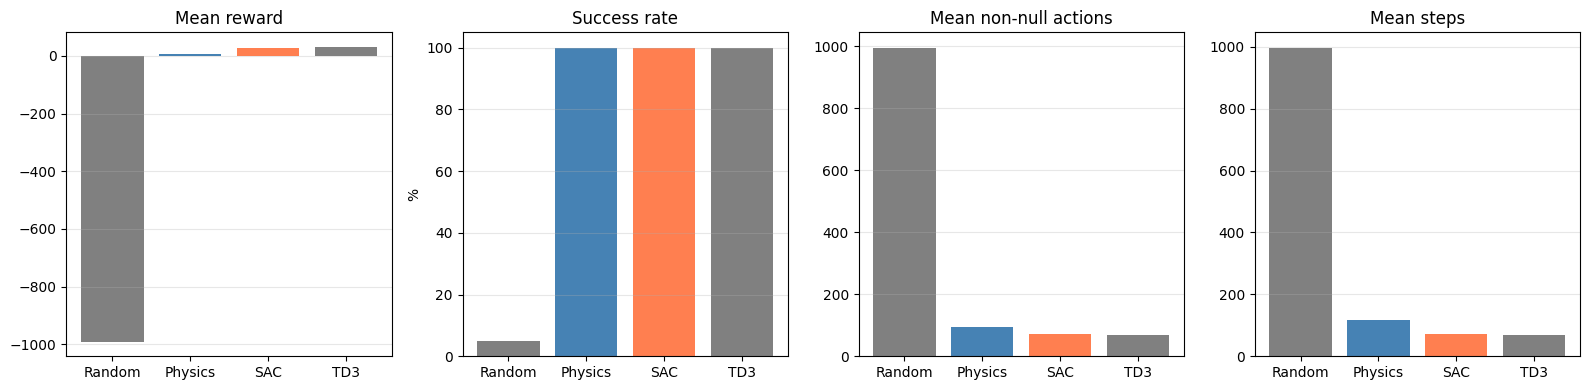

In [9]:
metric_names = ['mean_reward', 'success_rate', 'mean_non_null_actions', 'mean_steps']
metric_titles = ['Mean reward', 'Success rate', 'Mean non-null actions', 'Mean steps']
agent_names = list(evaluation_results.keys())

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric, title in zip(axes, metric_names, metric_titles):
    values = [evaluation_results[name][metric] for name in agent_names]
    if metric == 'success_rate':
        values = [100 * v for v in values]
    ax.bar(agent_names, values, color=['gray', 'steelblue', 'coral'][:len(agent_names)])
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
    if metric == 'success_rate':
        ax.set_ylabel('%')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 's04_evaluation_comparison.png', dpi=150)
plt.show()


## Section 8 - Visual Replay

This replay renders one deterministic episode for SAC and TD3 side by side. It is useful for checking that the numbers in the table match the actual behaviour of the car.

The printed replay metrics use the Scenario 4 wrapper, so the reward and non-null count are consistent with the rest of the notebook.


In [10]:
def collect_rendered_episode(model, agent_name='Agent', seed=12, max_steps=999):
    render_env = make_scenario4_env(render_mode='rgb_array')
    state, _ = render_env.reset(seed=seed)

    frames = [render_env.render()]
    total_reward = 0.0
    steps = 0
    non_null_actions = 0
    success = False
    done = False

    while not done and steps < max_steps:
        action, _ = model.predict(state, deterministic=True)
        state, reward, terminated, truncated, info = render_env.step(action)
        frames.append(render_env.render())
        total_reward += reward
        steps += 1
        done = terminated or truncated
        success = success or terminated
        non_null_actions = info.get('episode_non_null_actions', non_null_actions)

    render_env.close()
    return {
        'agent_name': agent_name,
        'frames': frames,
        'success': success,
        'steps': steps,
        'non_null_actions': non_null_actions,
        'total_reward': total_reward,
    }


def render_trained_episodes(model_dict, agent_names=('SAC', 'TD3'), seed=12, max_steps=999, interval=40):
    episodes = [
        collect_rendered_episode(model_dict[name], agent_name=name, seed=seed, max_steps=max_steps)
        for name in agent_names
        if name in model_dict
    ]
    if not episodes:
        raise ValueError('No requested agents are available in models.')

    max_frames = max(len(ep['frames']) for ep in episodes)
    fig, axes = plt.subplots(1, len(episodes), figsize=(6 * len(episodes), 4), squeeze=False)
    axes = axes.ravel()
    images = []

    for ax, ep in zip(axes, episodes):
        ax.axis('off')
        images.append(ax.imshow(ep['frames'][0]))

    def update(frame_idx):
        updated = []
        for ax, image, ep in zip(axes, images, episodes):
            shown_idx = min(frame_idx, len(ep['frames']) - 1)
            image.set_data(ep['frames'][shown_idx])
            ax.set_title(f"{ep['agent_name']} - Step {shown_idx}/{len(ep['frames']) - 1}")
            updated.append(image)
        return updated

    anim = animation.FuncAnimation(
        fig, update, frames=max_frames, interval=interval, blit=True
    )
    plt.close(fig)

    for ep in episodes:
        print(
            f"Rendered {ep['agent_name']}: success={ep['success']}, steps={ep['steps']}, "
            f"non_null={ep['non_null_actions']}, scenario4_reward={ep['total_reward']:.2f}"
        )
    return HTML(anim.to_jshtml())


display(render_trained_episodes(models, agent_names=('SAC', 'TD3')))


objc[80827]: Class SDLApplication is implemented in both /Users/michailsifakis/.pyenv/versions/3.12.0/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x289414890) and /Users/michailsifakis/.pyenv/versions/3.12.0/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x2a5a612c8). One of the two will be used. Which one is undefined.
objc[80827]: Class SDLAppDelegate is implemented in both /Users/michailsifakis/.pyenv/versions/3.12.0/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x2894148e0) and /Users/michailsifakis/.pyenv/versions/3.12.0/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x2a5a61318). One of the two will be used. Which one is undefined.
objc[80827]: Class SDLTranslatorResponder is implemented in both /Users/michailsifakis/.pyenv/versions/3.12.0/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x289414958) and /Users/michailsifakis/.pyenv/versions/3.12.0/lib/python3.12/site-packages/pygame/.dylibs/libSDL

Rendered TD3: success=True, steps=69, non_null=69, scenario4_reward=31.00


## Section 9 - Policy Heatmaps

The heatmaps show what each policy would do across the position-velocity state space.

For this scenario, the main question is not whether the force is small or large. The main question is where the agent decides to pay for a non-null action. A good policy should spend actions in the parts of the trajectory where pushing helps the car gain useful momentum.


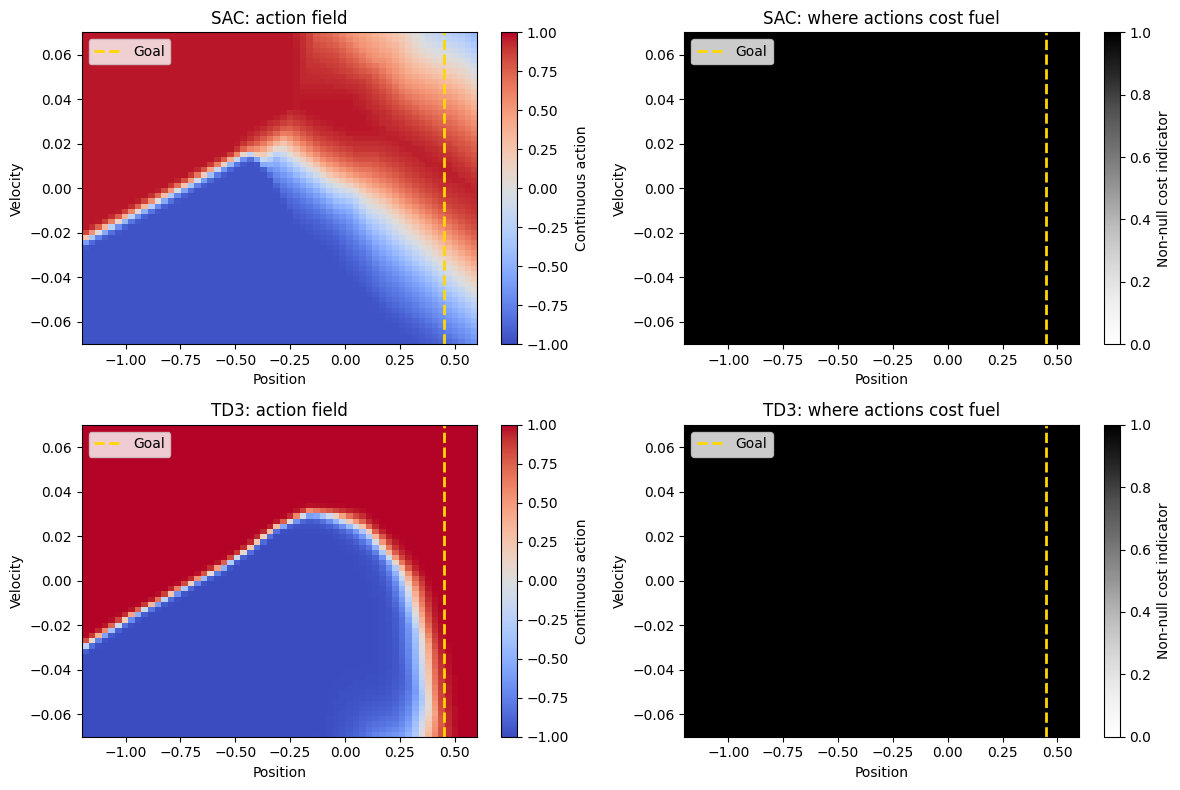

In [11]:
def plot_action_heatmaps(models, threshold=NON_NULL_THRESHOLD, n_grid=60):
    env = make_scenario4_env(non_null_threshold=threshold)
    pos, vel = state_grid(env, n_grid=n_grid)
    fig, axes = plt.subplots(len(models), 2, figsize=(12, 4 * len(models)), squeeze=False)

    for row, (name, model) in enumerate(models.items()):
        action_grid = np.zeros((n_grid, n_grid))
        cost_grid = np.zeros((n_grid, n_grid))
        for i, p in enumerate(pos):
            for j, v in enumerate(vel):
                a = model_action(model, np.array([p, v], dtype=np.float32))
                action_grid[j, i] = a
                cost_grid[j, i] = float(abs(a) > threshold)

        im0 = axes[row, 0].imshow(
            action_grid,
            extent=[pos[0], pos[-1], vel[0], vel[-1]],
            origin='lower',
            aspect='auto',
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
        )
        plt.colorbar(im0, ax=axes[row, 0], label='Continuous action')
        axes[row, 0].set_title(f'{name}: action field')

        im1 = axes[row, 1].imshow(
            cost_grid,
            extent=[pos[0], pos[-1], vel[0], vel[-1]],
            origin='lower',
            aspect='auto',
            cmap='Greys',
            vmin=0,
            vmax=1,
        )
        plt.colorbar(im1, ax=axes[row, 1], label='Non-null cost indicator')
        axes[row, 1].set_title(f'{name}: where actions cost fuel')

        for ax in axes[row]:
            ax.axvline(0.45, color='gold', ls='--', lw=2, label='Goal')
            ax.set_xlabel('Position')
            ax.set_ylabel('Velocity')
            ax.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig(CHECKPOINT_DIR / 's04_policy_heatmaps.png', dpi=150)
    plt.show()
    env.close()

plot_action_heatmaps(models)


## Section 10 - Phase Portraits and State Visitation

The phase portraits show the paths taken by the trained policies in physical state space. This is helpful because Mountain Car is really an energy-building problem: the car has to swing back and forth before it can climb the right hill.

The visitation plots show which states the policies actually pass through during successful episodes.


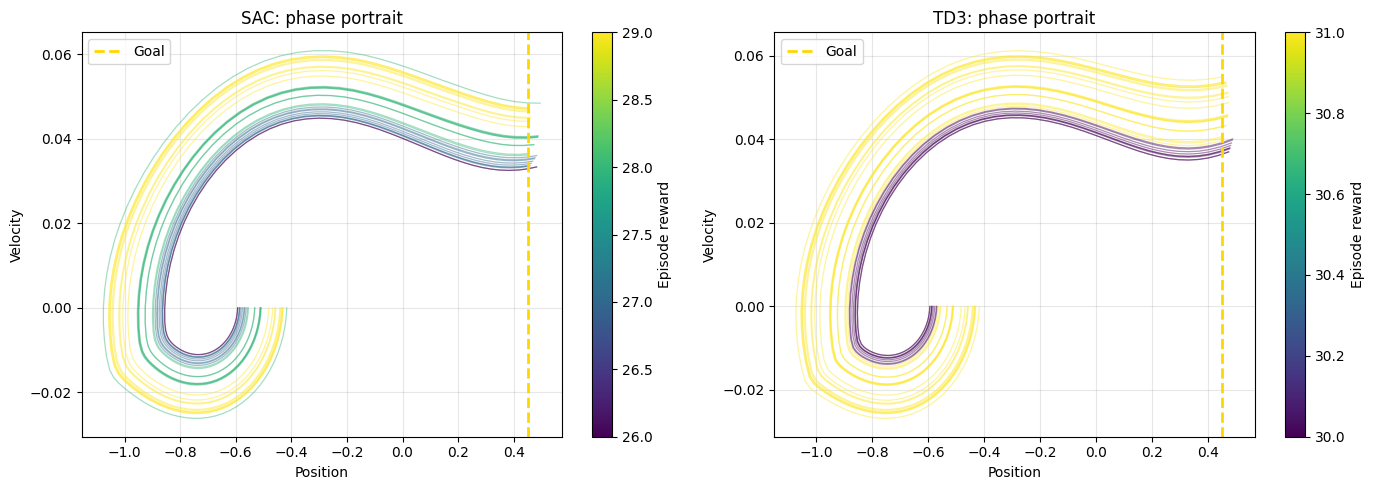

In [12]:
def collect_model_trajectories(model, n_episodes=30, seed=3000):
    env = make_scenario4_env()
    trajectories = []
    for ep in range(n_episodes):
        traj = rollout_policy(env, lambda s: model.predict(s, deterministic=True)[0], seed=seed + ep)
        trajectories.append(traj)
    env.close()
    return trajectories

trajectory_sets = {name: collect_model_trajectories(model) for name, model in models.items()}

fig, axes = plt.subplots(1, len(trajectory_sets), figsize=(7 * len(trajectory_sets), 5), squeeze=False)
for ax, (name, trajs) in zip(axes.flat, trajectory_sets.items()):
    rewards = [t['total_reward'] for t in trajs]
    vmin, vmax = min(rewards), max(rewards)
    cmap = plt.cm.viridis
    for traj in trajs:
        states = traj['states']
        color = cmap((traj['total_reward'] - vmin) / max(vmax - vmin, 1e-8))
        ax.plot(states[:, 0], states[:, 1], alpha=0.45, lw=0.9, color=color)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Episode reward')
    ax.axvline(0.45, color='gold', ls='--', lw=2, label='Goal')
    ax.set_title(f'{name}: phase portrait')
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 's04_phase_portraits.png', dpi=150)
plt.show()


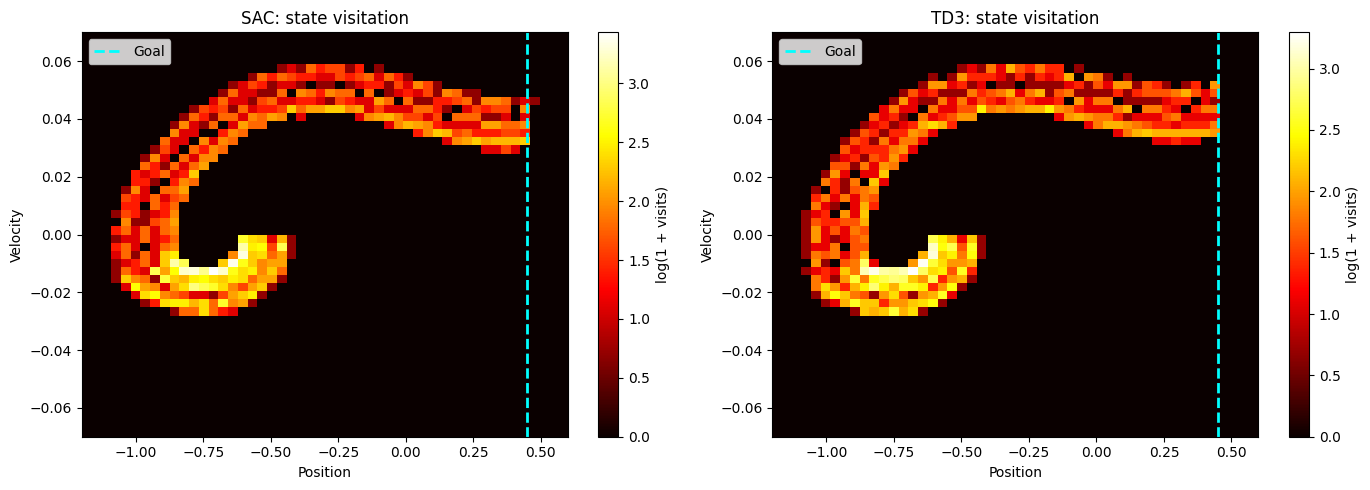

In [13]:
def build_visit_grid_from_trajectories(trajs, env, n_grid=50):
    pos_low, vel_low = env.observation_space.low
    pos_high, vel_high = env.observation_space.high
    grid = np.zeros((n_grid, n_grid))
    for traj in trajs:
        for s in traj['states']:
            pi = int(np.clip((s[0] - pos_low) / (pos_high - pos_low) * (n_grid - 1), 0, n_grid - 1))
            vi = int(np.clip((s[1] - vel_low) / (vel_high - vel_low) * (n_grid - 1), 0, n_grid - 1))
            grid[pi, vi] += 1
    return grid

env_for_grid = make_scenario4_env()
fig, axes = plt.subplots(1, len(trajectory_sets), figsize=(7 * len(trajectory_sets), 5), squeeze=False)
for ax, (name, trajs) in zip(axes.flat, trajectory_sets.items()):
    grid = build_visit_grid_from_trajectories(trajs, env_for_grid)
    pos_low, vel_low = env_for_grid.observation_space.low
    pos_high, vel_high = env_for_grid.observation_space.high
    im = ax.imshow(np.log1p(grid).T, extent=[pos_low, pos_high, vel_low, vel_high], origin='lower', cmap='hot', aspect='auto')
    plt.colorbar(im, ax=ax, label='log(1 + visits)')
    ax.axvline(0.45, color='cyan', ls='--', lw=2, label='Goal')
    ax.set_title(f'{name}: state visitation')
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')
    ax.legend()
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 's04_state_visitation.png', dpi=150)
plt.show()
env_for_grid.close()


## Section 11 - Action-Time Analysis

This plot follows one rollout step by step. The left side shows the continuous force chosen by the policy, and the shaded area marks the timesteps where the action costs fuel.

The important point is that every non-null action costs the same. The agent gets no discount for tiny non-zero actions, so a good policy should avoid unnecessary jitter around zero.


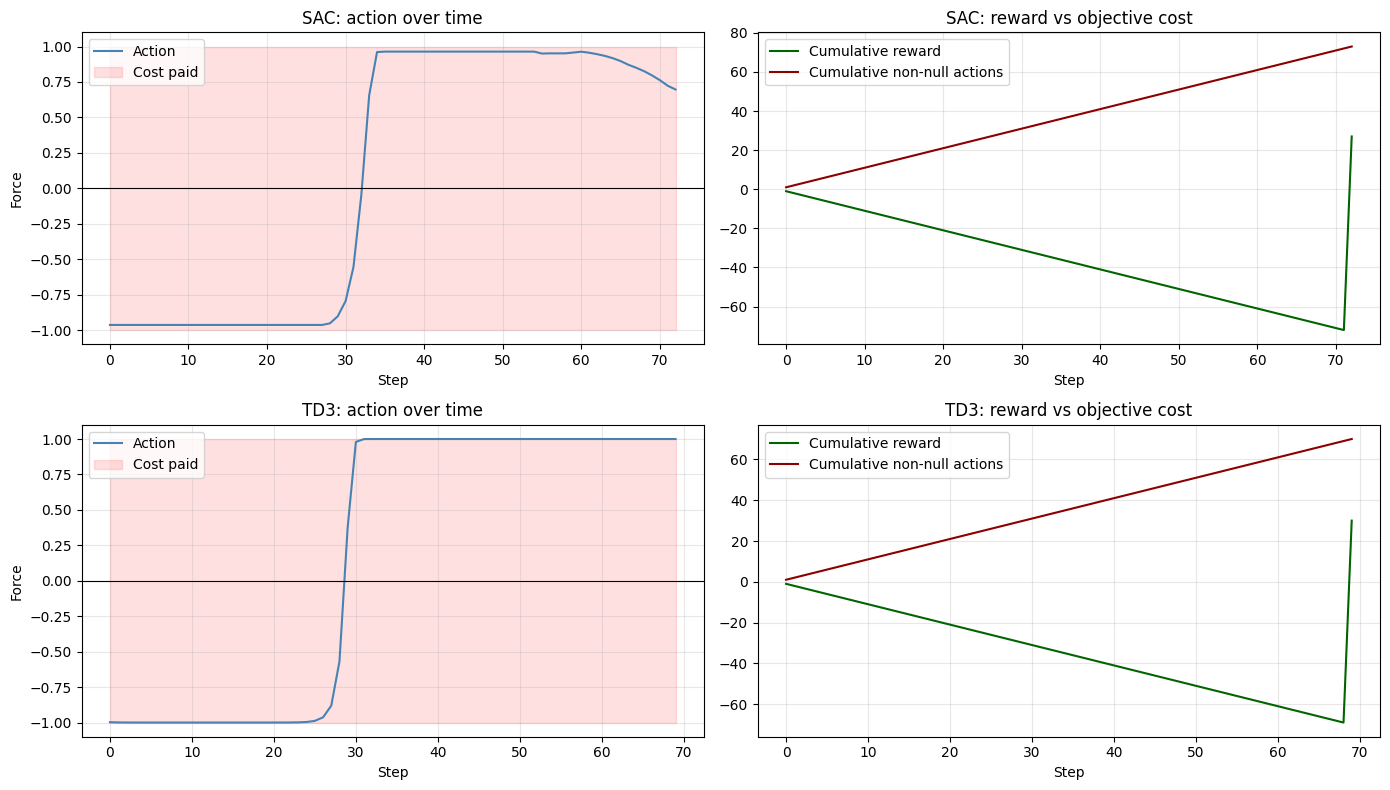

In [14]:
fig, axes = plt.subplots(len(models), 2, figsize=(14, 4 * len(models)), squeeze=False)
for row, (name, model) in enumerate(models.items()):
    env = make_scenario4_env()
    traj = rollout_policy(env, lambda s: model.predict(s, deterministic=True)[0], seed=5000)
    env.close()
    actions = traj['actions']
    rewards = traj['rewards']
    non_null = np.abs(actions) > NON_NULL_THRESHOLD
    t = np.arange(len(actions))

    axes[row, 0].plot(t, actions, color='steelblue', lw=1.5, label='Action')
    axes[row, 0].fill_between(t, -1, 1, where=non_null, color='red', alpha=0.12, label='Cost paid')
    axes[row, 0].axhline(0, color='black', lw=0.8)
    axes[row, 0].set_title(f'{name}: action over time')
    axes[row, 0].set_xlabel('Step')
    axes[row, 0].set_ylabel('Force')
    axes[row, 0].legend()
    axes[row, 0].grid(alpha=0.3)

    axes[row, 1].plot(np.cumsum(rewards), color='darkgreen', lw=1.5, label='Cumulative reward')
    axes[row, 1].plot(np.cumsum(non_null), color='darkred', lw=1.5, label='Cumulative non-null actions')
    axes[row, 1].set_title(f'{name}: reward vs objective cost')
    axes[row, 1].set_xlabel('Step')
    axes[row, 1].legend()
    axes[row, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 's04_action_time_analysis.png', dpi=150)
plt.show()


## Section 12 - Policy Explanation With Simple Models

The decision tree is only used as an explanation tool. It is not controlling the car.

I use it to approximate two things: when the neural policy chooses a null/non-null action, and whether position or velocity is more important for predicting the continuous action. This gives a simpler way to describe the learned behaviour in the report.



SAC non-null classifier tree:
|--- position <= 0.29
|   |--- class: 1
|--- position >  0.29
|   |--- position <= 0.29
|   |   |--- class: 0
|   |--- position >  0.29
|   |   |--- velocity <= -0.03
|   |   |   |--- velocity <= -0.03
|   |   |   |   |--- class: 1
|   |   |   |--- velocity >  -0.03
|   |   |   |   |--- class: 0
|   |   |--- velocity >  -0.03
|   |   |   |--- class: 1

SAC action regressor feature importances:
  position: 0.183
  velocity: 0.817

TD3 non-null classifier tree:
|--- class: 0

TD3 action regressor feature importances:
  position: 0.388
  velocity: 0.612


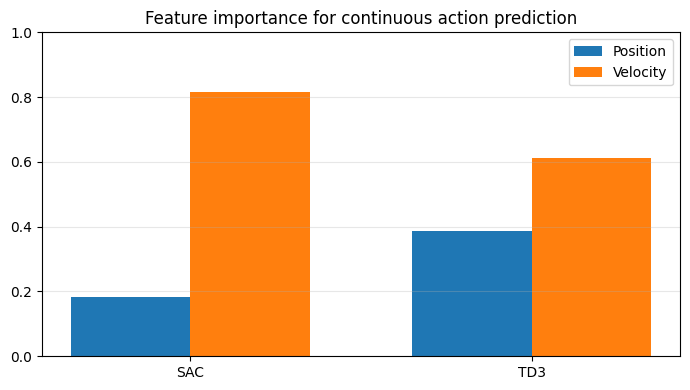

In [15]:
def explain_policy(model, name, n_samples=8000, threshold=NON_NULL_THRESHOLD):
    env = make_scenario4_env()
    rng = np.random.default_rng(SEED)
    low = env.observation_space.low
    high = env.observation_space.high
    X = rng.uniform(low, high, size=(n_samples, 2)).astype(np.float32)
    actions = np.array([model_action(model, s) for s in X])
    y_non_null = (np.abs(actions) > threshold).astype(int)

    classifier = DecisionTreeClassifier(max_depth=4, random_state=SEED)
    classifier.fit(X, y_non_null)

    regressor = DecisionTreeRegressor(max_depth=4, random_state=SEED)
    regressor.fit(X, actions)

    print(f'\n{name} non-null classifier tree:')
    print(export_text(classifier, feature_names=['position', 'velocity']))
    print(f'{name} action regressor feature importances:')
    print(f'  position: {regressor.feature_importances_[0]:.3f}')
    print(f'  velocity: {regressor.feature_importances_[1]:.3f}')
    env.close()
    return classifier, regressor

explainers = {name: explain_policy(model, name) for name, model in models.items()}

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(models))
width = 0.35
position_importance = [explainers[name][1].feature_importances_[0] for name in models]
velocity_importance = [explainers[name][1].feature_importances_[1] for name in models]
ax.bar(x - width/2, position_importance, width, label='Position')
ax.bar(x + width/2, velocity_importance, width, label='Velocity')
ax.set_xticks(x)
ax.set_xticklabels(list(models.keys()))
ax.set_ylim(0, 1)
ax.set_title('Feature importance for continuous action prediction')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 's04_feature_importance.png', dpi=150)
plt.show()


## Section 13 - Results Interpretation and Conclusions

This section turns the final numbers into the main takeaway for Scenario 4. The text is generated from `evaluation_results`, so if the training setup is changed and rerun, the conclusion should update with the new metrics.


In [16]:
def summarize_scenario4_results(results):
    learned_agents = {
        name: metrics
        for name, metrics in results.items()
        if name not in {'Random', 'Physics'}
    }
    successful_agents = {
        name: metrics
        for name, metrics in learned_agents.items()
        if metrics['success_rate'] >= 0.8
    }
    unsuccessful_agents = {
        name: metrics
        for name, metrics in learned_agents.items()
        if metrics['success_rate'] < 0.8
    }

    print('My Scenario 4 takeaway')
    print('-' * 40)
    if successful_agents:
        best_name, best_metrics = min(
            successful_agents.items(),
            key=lambda item: item[1]['mean_non_null_actions'],
        )
        print(
            f'The best RL result in this run is {best_name}: '
            f'{100 * best_metrics["success_rate"]:.0f}% success, '
            f'{best_metrics["mean_non_null_actions"]:.1f} non-null actions on average, '
            f'and mean reward {best_metrics["mean_reward"]:.2f}.'
        )
    else:
        print('No RL agent reached the 80% success threshold yet, so I would train longer or tune exploration.')

    for name, metrics in unsuccessful_agents.items():
        print(
            f'{name} did not solve the task in this run: '
            f'{100 * metrics["success_rate"]:.0f}% success and '
            f'{metrics["mean_non_null_actions"]:.1f} non-null actions.'
        )

    random_metrics = results.get('Random')
    if random_metrics and successful_agents:
        improvement = random_metrics['mean_non_null_actions'] - best_metrics['mean_non_null_actions']
        print(
            f'Compared with random actions, {best_name} uses about '
            f'{improvement:.1f} fewer non-null actions per episode.'
        )

    physics_metrics = results.get('Physics')
    if physics_metrics and successful_agents:
        improvement = physics_metrics['mean_non_null_actions'] - best_metrics['mean_non_null_actions']
        print(
            f'It also improves on the simple physics baseline by about '
            f'{improvement:.1f} non-null actions per episode.'
        )

    print('\nConclusion I would use in the report:')
    print(
        'For Scenario 4, the main goal is not just reaching the flag, but reaching it while paying '
        'for as few non-null continuous actions as possible.'
    )
    if successful_agents:
        print(
            f'In my run, {best_name} is the strongest policy: it reaches the goal every time and '
            'uses fewer paid actions than both random exploration and the simple physics baseline. '
            'This suggests that the agent learned to spend strong actions only where they help build enough momentum.'
        )
    else:
        print(
            'In my current run, no RL agent solves this objective yet. I would next increase the training budget '
            'or tune exploration so the agent sees more successful episodes.'
        )


summarize_scenario4_results(evaluation_results)


My Scenario 4 takeaway
----------------------------------------
The best RL result in this run is TD3: 100% success, 69.2 non-null actions on average, and mean reward 30.75.
Compared with random actions, TD3 uses about 926.5 fewer non-null actions per episode.
It also improves on the simple physics baseline by about 24.8 non-null actions per episode.

Conclusion I would use in the report:
For Scenario 4, the main goal is not just reaching the flag, but reaching it while paying for as few non-null continuous actions as possible.
In my run, TD3 is the strongest policy: it reaches the goal every time and uses fewer paid actions than both random exploration and the simple physics baseline. This suggests that the agent learned to spend strong actions only where they help build enough momentum.


### Final Report

- **Compared with Scenario 2:** Scenario 2 penalises action magnitude because the cost is quadratic. Scenario 4 is different: after the action passes the non-null threshold, a small push and a full push both cost one unit. In my results, the learned policies mostly use strong pushes, but for fewer timesteps.
- **Compared with Scenario 3:** Scenario 3 and Scenario 4 are both fuel-saving tasks. Scenario 3 has discrete actions, while Scenario 4 keeps the force continuous. Because of that, the main thing to analyse here is *when* the policy chooses to pay for an action.
- **Reward and objective:** The reward matches the objective directly: `reward = 100 * success - non_null_action_count`. A good score means the car reached the goal and did it with fewer paid actions. A policy that simply avoids acting but never reaches the flag would not count as a good solution.
- **Model comparison:** SAC solves the task well with standard continuous-control training. TD3 also solves it after the replay warm-start from the physics controller. I would describe the warm-start as an exploration aid, not as a change to the objective, because TD3 is still evaluated with exactly the same Scenario 4 reward as SAC.
